# Занятие 3. Слой LangChain 1.x: create_agent, middleware, проектирование инструментов

**`create_agent` собирает граф агента из занятия 2 одним вызовом.**

- `create_agent` получает модель, инструменты и системный промпт и строит граф с узлами `model` и `tools`
- хук — ваша функция, которую агент вызывает в заданном месте цикла; middleware — объект с одним или несколькими хуками
- дальше: правила для инструментов, JSON-схема (описание инструмента для модели) и расчет стоимости прогона по токенам
- первая ячейка — настройка из занятия 2: `chat_model()` создает модель по `.env`, `draw(graph)` рисует граф

In [ ]:
# Настроить chat_model и draw для всего ноутбука: модель по настройкам .env и рисунок графа.

import os

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain.chat_models import init_chat_model

load_dotenv()  # копирует переменные из .env в os.environ; уже заданные не трогает


def chat_model(size: str = "cheap", **kwargs):
    """A model object for the configured provider. A dozen lines, copy them once."""
    name = os.environ[f"MODEL_{size.upper()}"]  # MODEL_CHEAP или MODEL_STRONG из .env
    secret = os.environ["LLM_API_KEY"]
    # в прогонах курса gpt-5.x требовал reasoning_effort=none для работы с инструментами
    if os.getenv("LLM_REASONING_EFFORT"):
        kwargs.setdefault("reasoning_effort", os.environ["LLM_REASONING_EFFORT"])
    kwargs.setdefault("timeout", 120)  # 2 минуты на попытку; у ChatOpenAI по умолчанию без срока
    kwargs.setdefault("max_tokens", 8192)  # ограничивает длину ответа 8192 токенами
    # Gemini давал 400 после инструмента через OpenAI-совместимый адрес; нужен свой клиент
    if os.getenv("LLM_PROVIDER", "openai_compat") == "google_genai":
        # префикс до двоеточия выбирает класс: google_genai дает ChatGoogleGenerativeAI
        return init_chat_model(f"google_genai:{name}", api_key=secret, **kwargs)
    return init_chat_model(  # openai дает ChatOpenAI; запросы идут на адрес LLM_BASE_URL
        f"openai:{name}", api_key=secret, base_url=os.environ["LLM_BASE_URL"], **kwargs
    )


def draw(graph) -> None:
    """Show a compiled graph as a picture, or as Mermaid text when offline."""
    try:  # PNG рисует сайт mermaid.ink: ему отправляется только текст графа
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:  # при ошибке отрисовки показать тот же граф текстом
        print(graph.get_graph().draw_mermaid())


print("provider:", os.getenv("LLM_PROVIDER", "openai_compat"),
      "| strong:", os.environ["MODEL_STRONG"])

## create_agent

**До LangGraph 1.0 агента собирала `create_react_agent` из `langgraph.prebuilt`, теперь ее заменяет `create_agent` из `langchain.agents`.**

- старое имя еще работает; импорт проходит без предупреждения, оно появляется только при вызове
- следующая ячейка вызывает `create_react_agent` и печатает категорию `LangGraphDeprecatedSinceV10` и текст предупреждения
- в тексте названа замена и сказано, что старое имя удалят в LangGraph V2.0
- ячейка также создает `model = chat_model("strong")` для следующих ячеек; запросов к модели в ней нет

In [ ]:
# Вызвать create_react_agent: предупреждение об устаревании укажет, какой функцией ее заменить.

import warnings

from langgraph.prebuilt import create_react_agent  # сам импорт проходит молча

model = chat_model("strong")  # сильная модель; ее возьмут агент и ручной граф ниже

# внутри блока with предупреждения пишутся в список caught
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")  # записывать все, даже те, что Python скрывает
    create_react_agent(model, [])  # предупреждение срабатывает здесь, при вызове

# отбор по категории: первым могло записаться постороннее предупреждение
w = next(w for w in caught if "Deprecated" in w.category.__name__)
print(w.category.__name__)  # класс предупреждения: устарело в LangGraph 1.0, удалят в 2.0
print(w.message)  # текст называет замену: create_agent из langchain.agents

**Пример занятия — валютная справочная: таблица курсов `RATES` и два инструмента.**

- курсы выдуманы и записаны в коде, поэтому сеть не нужна и в каждом прогоне числа те же
- `currency_rate` возвращает курс одной валюты к доллару, `currency_convert` переводит сумму между валютами через доллар
- на неизвестный код инструмент возвращает строку с известными кодами и не бросает исключение, как требует правило занятия 1
- в конце ячейка вызывает `currency_rate` без модели, через `.invoke`, и печатает курс `EUR` и ответ на неизвестный `XAU`
- префикс `currency_` и флаг `parse_docstring=True` разобраны ниже, в разделах «Проектирование инструментов» и «Что уходит в запрос к модели»

In [ ]:
# Объявить два валютных инструмента: фиксированные курсы и подсказка при неизвестном коде валюты.

from langchain_core.tools import tool

# выдуманная таблица курсов: без сети, в каждом прогоне те же числа
RATES = {"EUR": 1.09, "GBP": 1.27, "JPY": 0.0064, "CHF": 1.13, "USD": 1.0}


@tool  # докстрока — это описание, которое читает модель
def currency_rate(code: str) -> str:  # имя функции — имя инструмента; code — поле JSON-схемы
    """Return the USD rate for one ISO currency code, for example EUR."""
    code = code.strip().upper()  # модель может прислать « eur »; станет «EUR»
    if code not in RATES:
        # известные коды помогут модели исправить запрос
        return f"Unknown code {code!r}. Known codes: {', '.join(sorted(RATES))}."
    return f"1 {code} = {RATES[code]} USD"


@tool(parse_docstring=True)  # строки Args: перейдут в описания параметров схемы
def currency_convert(amount: float, source: str, target: str) -> str:  # float в схеме — number
    """Convert an amount between two currencies via USD.

    Args:
        amount: The amount in the source currency.
        source: ISO code the amount is in, for example EUR.
        target: ISO code to convert into, for example JPY.
    """
    source, target = source.strip().upper(), target.strip().upper()
    unknown = [c for c in (source, target) if c not in RATES]
    if unknown:
        return f"Unknown codes: {', '.join(unknown)}. Known: {', '.join(sorted(RATES))}."
    # пересчет через доллар: умножить на курс source, разделить на курс target
    return f"{amount} {source} = {amount * RATES[source] / RATES[target]:.2f} {target}"


TOOLS = [currency_rate, currency_convert]  # список для агентов и ручного графа ниже
print(currency_rate.invoke({"code": "eur"}))  # инструмент запускают .invoke со словарем
print(currency_rate.invoke({"code": "XAU"}))  # кода нет: вернется строка, без исключения

**`create_agent` из `langchain.agents` собирает агента занятия 2 одним вызовом.**

- на вход: объект модели `model`, список `TOOLS` и системный промпт `PROMPT`; на выходе скомпилированный граф, как после `builder.compile()`
- поэтому `invoke` получает тот же словарь состояния с ключом `messages`; словарь с ролью `user` становится `HumanMessage`
- `recursion_limit` — предохранитель занятия 2, он ограничивает число шагов графа и прерывает слишком долгий прогон с ошибкой
- следующая ячейка спрашивает «What is the euro worth in dollars?» и печатает все сообщения результата через `pretty_print()`
- системного сообщения в выводе не будет, потому что `create_agent` отправляет промпт с каждым запросом, но в историю не пишет

In [ ]:
# Собрать агента занятия 2 через create_agent и напечатать сообщения: вопрос, вызов инструмента и ответ.

from langchain.agents import create_agent

# системный промпт: create_agent ставит его первым сообщением в каждый запрос к модели
PROMPT = "You are a currency desk assistant. Use the tools for every rate."

agent = create_agent(model, TOOLS, system_prompt=PROMPT)  # граф с узлами model и tools

result = agent.invoke(  # прогон до конца цикла; вернется итоговое состояние
    # входное состояние: словарь с ролью user станет сообщением HumanMessage
    {"messages": [{"role": "user", "content": "What is the euro worth in dollars?"}]},
    # шаг: запускаются все готовые узлы; вызовы инструментов ответа идут в одном шаге
    config={"recursion_limit": 8},  # предохранитель: прогон длиной 8 шагов и больше падает
)

for message in result["messages"]:  # вся история прогона, начиная с вопроса
    message.pretty_print()  # роль, текст и вызовы инструментов каждого сообщения

## Граф внутри

**В прогоне курса агент сделал один виток цикла и записал четыре сообщения, как граф занятия 2.**

- `Human` — вопрос, `AI` — запрос модели на вызов `currency_rate`, `Tool` — результат, `AI` — ответ без вызовов
- на рисунке справа от каждого сообщения узел, который его записал; вопрос приходит на вход через `__start__`
- следующая ячейка собирает граф занятия 2 руками, рисует оба графа и печатает ребра, которые есть только в одном
- так сравнивается структура графов; граф `by_hand` только собирается, модель не вызывается

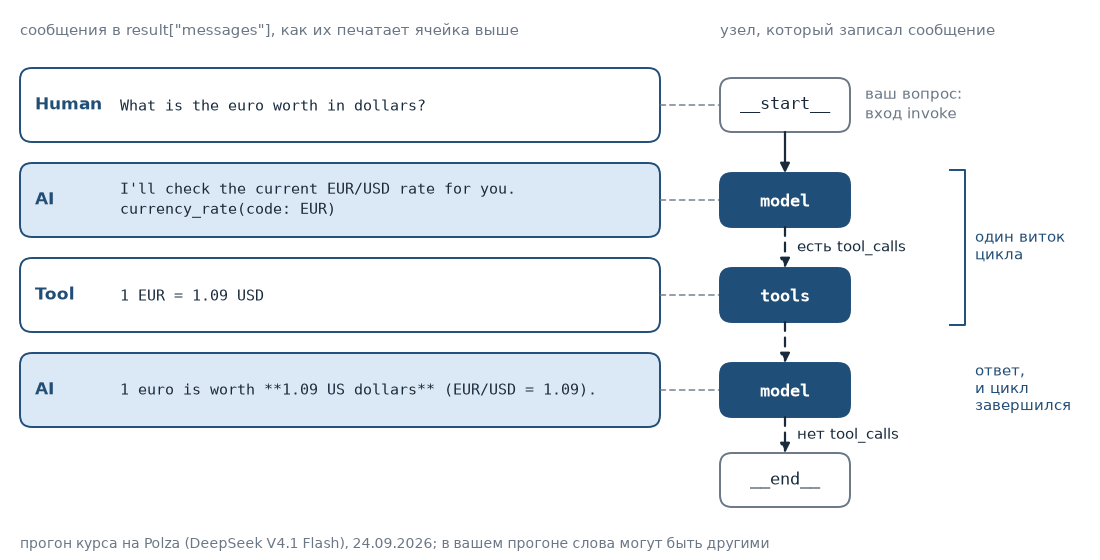

In [ ]:
# Сравнить граф занятия 2 с графом create_agent: нарисовать оба и найти различия в ребрах.

from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode

bound = model.bind_tools(TOOLS)  # модель со схемами инструментов; граф только рисуют


def call_model(state: MessagesState) -> dict:
    # вернуть только новый ответ: add_messages из MessagesState допишет его к истории
    return {"messages": [bound.invoke(state["messages"])]}


def should_continue(state: MessagesState) -> str:
    # есть вызовы инструментов в последнем ответе: в узел tools, иначе конец прогона
    return "tools" if state["messages"][-1].tool_calls else END


# редьюсер поля решает, как обновление узла попадет в состояние; тут add_messages
builder = StateGraph(MessagesState)  # граф над схемой MessagesState: одно поле messages
builder.add_node("model", call_model)
builder.add_node("tools", ToolNode(TOOLS))  # выполнит все вызовы из последнего ответа
builder.add_edge(START, "model")
# условное ребро: следующий узел выбирает should_continue, список — допустимые цели
builder.add_conditional_edges("model", should_continue, ["tools", END])
builder.add_edge("tools", "model")  # замыкает цикл; один проход model и tools — виток
by_hand = builder.compile()  # compile собирает граф, модель при этом не вызывается

print("--- session 2, by hand ---")
draw(by_hand)  # draw объявлена в первой ячейке
print("--- create_agent ---")
draw(agent)


def edges(graph) -> set:
    # пунктир на рисунке — условное ребро, у него conditional=True
    return {(e.source, e.target, "dashed" if e.conditional else "solid")
            for e in graph.get_graph().edges}  # тройка на ребро: откуда, куда, вид линии


print("only by hand:     ", edges(by_hand) - edges(agent))
print("only create_agent:", edges(agent) - edges(by_hand))

**У двух графов одинаковые узлы `model` и `tools`; одно ребро нарисовано иначе.**

- в выводе `only by hand` — ребро `('tools', 'model', 'solid')`, `only create_agent` — то же ребро с `'dashed'`
- пунктир — условное ребро: функция внутри `create_agent` выбирает узел и может закончить прогон, например при `return_direct=True` у всех вызванных инструментов
- у справочной таких настроек нет, поэтому на рисунке из `tools` выходит одно ребро, к `model`
- документация LangChain начинает с `create_agent` и советует переходить к графу, когда возможностей `create_agent` не хватает
- курс показал граф первым: `create_agent` собирает тот же граф, поэтому после занятия 2 устройство этого вызова уже знакомо

## content_blocks

**Свойство `.content_blocks` дает ответ модели списком блоков в одном формате для разных провайдеров.**

- `.content` хранит ответ в формате провайдера; у одного это реплика, у другого пустая строка рядом с вызовом инструмента
- `.content_blocks` собирает из `.content` и вызовов инструментов список словарей с полем `type`; `.content` при этом не меняется
- текст дает блок `{"type": "text", ...}`, вызов инструмента — блок `{"type": "tool_call", ...}`
- следующая ячейка печатает оба поля у двух ответов первого прогона: ответа с вызовом инструмента и последнего

In [ ]:
# Сравнить .content и .content_blocks: у блоков общий формат для разных провайдеров.

tool_turn = result["messages"][1]  # ответ, в котором модель попросила инструмент
final_turn = result["messages"][-1]

# .content в формате провайдера; repr покажет и пустую строку ''
print("tool turn  .content:       ", repr(tool_turn.content))
# content_blocks собирается из .content и tool_calls, сам .content не меняется
print("tool turn  .content_blocks:", tool_turn.content_blocks)
print("final turn .content:       ", repr(final_turn.content))
print("final turn .content_blocks:", final_turn.content_blocks)

**В двух записанных прогонах курса `.content` ответа с вызовом разный, блок `tool_call` есть у обоих.**

| прогон | `.content` ответа с вызовом | `.content_blocks` ответа с вызовом |
|---|---|---|
| Polza, DeepSeek V4.1 Flash, 24.09.2026 | реплика модели «I'll check the current EUR/USD rate for you.» | блок `text`, за ним блок `tool_call` |
| OpenAI, gpt-5.6-luna, 17.09.2026 | пустая строка `''` | только блок `tool_call` |

- код, который считает пустой `.content` признаком вызова, на Polza ошибется; блок `tool_call` есть в обоих прогонах

## Middleware

**Middleware встраивает ваш код в цикл `create_agent` через хуки; на рисунке четыре хука этого занятия.**

- `before_model` и `after_model` — узлы графа перед запросом к модели и после ее ответа; они могут менять состояние
- `wrap_model_call` и `wrap_tool_call` — обертки, они работают внутри узла `model` или `tools`, вокруг самого вызова
- на занятии 2 свой код добавляли узлом графа; граф `create_agent` строит сам, и свой код в него добавляют хуками
- декоратор с именем хука из `langchain.agents.middleware` делает из функции middleware с одним хуком; список передают в `create_agent(..., middleware=[...])`

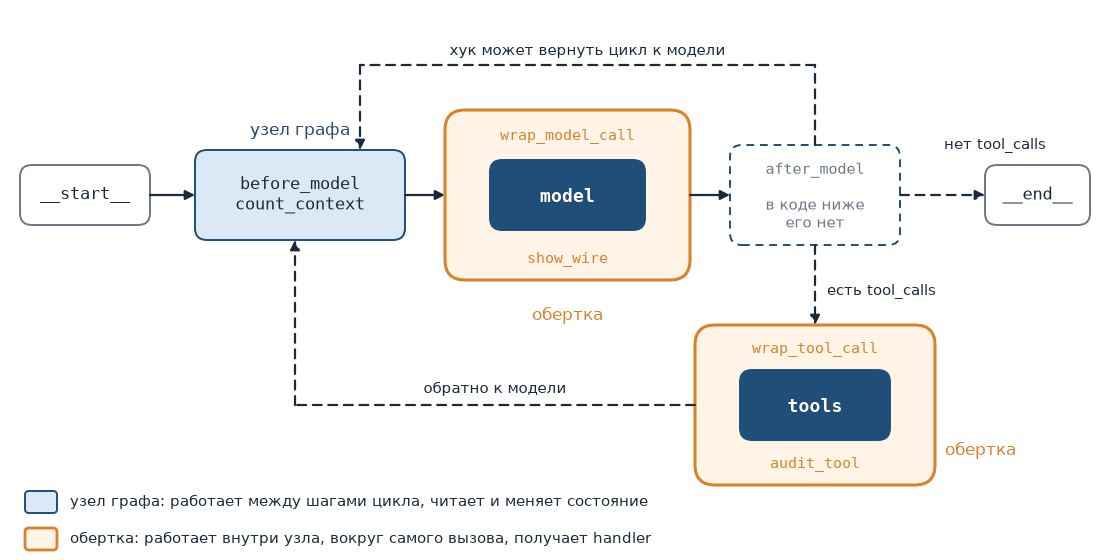

**`wrap_tool_call` получает запрос `request` и функцию `handler`, которая запускает инструмент.**

- до вызова `handler(request)` хук видит в `request.tool_call` имя инструмента и аргументы, после — `ToolMessage` с ответом
- чтобы запретить вызов, хук возвращает свой `ToolMessage` и не вызывает `handler`; модель получит этот текст как ответ инструмента
- следующая ячейка собирает агента с тремя хуками, которые печатают события цикла: `before_model`, `wrap_model_call` и `wrap_tool_call`
- в прогоне курса 24.09.2026 они напечатали 1 сообщение перед первым запросом, вызов `currency_rate({'code': 'GBP'})` и 3 сообщения перед вторым
- системного промпта среди этих сообщений нет; `draw(watched)` покажет новый узел `count_context.before_model`, обертки узлов не добавляют

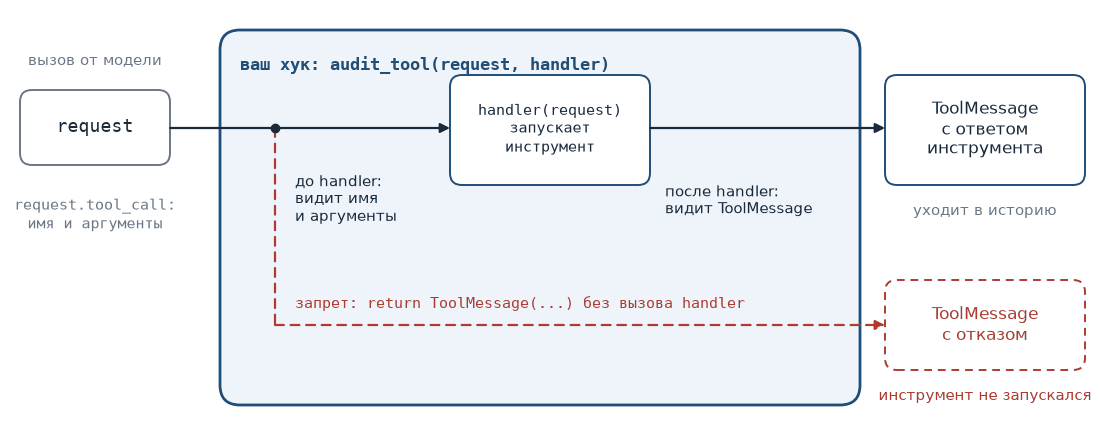

In [ ]:
# Добавить три хука, нарисовать граф и запустить агента: по выводу видно, когда срабатывает каждый хук.

# middleware — объект с хуками: функциями, которые агент вызывает в своем цикле
from langchain.agents.middleware import before_model, wrap_model_call, wrap_tool_call


@before_model  # делает из функции middleware; в графе это узел перед каждым вызовом модели
def count_context(state, runtime):  # runtime здесь не нужен, но обязателен в сигнатуре
    # без return хук ничего не меняет в состоянии
    print(f"[before_model] sending {len(state['messages'])} messages")


@wrap_model_call  # оборачивает каждый вызов модели
def show_wire(request, handler):  # request — запрос к модели, handler — сам вызов модели
    names = [t.name for t in request.tools]  # инструменты, чьи схемы идут с этим запросом
    # системный промпт лежит отдельно, в request.system_message, в это число не входит
    print(f"[wrap_model_call] {len(request.messages)} messages, tools {names}")
    return handler(request)  # вызвать модель и вернуть ее ответ циклу


@wrap_tool_call  # оборачивает каждое выполнение инструмента
def audit_tool(request, handler):
    # request.tool_call — вызов из ответа модели: имя, аргументы и id
    print(f"[wrap_tool_call] {request.tool_call['name']}({request.tool_call['args']})")
    # чтобы не запускать инструмент, верните свой ToolMessage вместо вызова handler
    return handler(request)  # запустить инструмент и вернуть его ответ


# декораторы уже превратили три функции в объекты middleware
watched = create_agent(chat_model("strong"), TOOLS, system_prompt=PROMPT,
                       middleware=[count_context, show_wire, audit_tool])
draw(watched)  # новый узел count_context.before_model; обертки узлов не добавляют

reply = watched.invoke(
    {"messages": [{"role": "user", "content": "How many dollars is one pound?"}]},
    # с before_model виток — три шага; 8 хватает только на один
    config={"recursion_limit": 12},  # before_model — лишний узел на каждом витке, 8 мало
)
print("final:", reply["messages"][-1].content)

**Готовые middleware — классы из `langchain.agents.middleware` для частых задач.**

- `PIIMiddleware` ищет личные данные (PII) заданного типа в последнем сообщении пользователя и заменяет их до запроса к модели
- `SummarizationMiddleware` заменяет старую часть длинной истории кратким пересказом; на занятии 4 это делают руками, на занятии 12 этим классом
- `HumanInTheLoopMiddleware` останавливает агента перед инструментом, требующим одобрения и ждет подтверждения человека; это тема занятия 6
- в том же модуле есть классы для повторов при сбое, запасной модели, лимитов числа вызовов и списка задач
- следующая ячейка добавляет `PIIMiddleware("email")` на агента без инструментов и печатает сохраненный вопрос с адресом, замененным на `[REDACTED_EMAIL]`

In [ ]:
# Добавить PIIMiddleware и напечатать сообщение пользователя: адрес скрывается до вызова модели.

from langchain.agents.middleware import PIIMiddleware

# готовый middleware: найденный email заменяется на [REDACTED_EMAIL] до вызова модели
guarded = create_agent(chat_model("cheap"), [], middleware=[PIIMiddleware("email")],
                       system_prompt="You are a currency desk assistant.")

out = guarded.invoke(
    {"messages": [{"role": "user", "content": "Mail the sheet to dana.lee@example.edu."}]},
    config={"recursion_limit": 8},
)
print(out["messages"][0].content)  # сообщение пользователя после замены адреса

## Что уходит в запрос к модели

**Модель узнает об инструменте из JSON-схемы; `@tool` строит ее из имени функции, аннотаций параметров и докстроки.**

- следующая ячейка печатает схему `currency_rate` функцией `convert_to_openai_tool` из `langchain_core.utils.function_calling`
- потом создает объект `ChatOpenAI` из `langchain_openai` и вызывает `bind_tools(TOOLS)`; так схемы будут в формате OpenAI при любом провайдере в `.env`
- `bind_tools` с занятия 2 ничего не отправляет, только сохраняет аргумент запроса `tools`; вывод — `['tools']` и имена инструментов в нем
- ячейка после нее объявляет `currency_convert` заново под именем `convert_plain`, без `parse_docstring=True`, и печатает параметры схемы и описание обоих инструментов

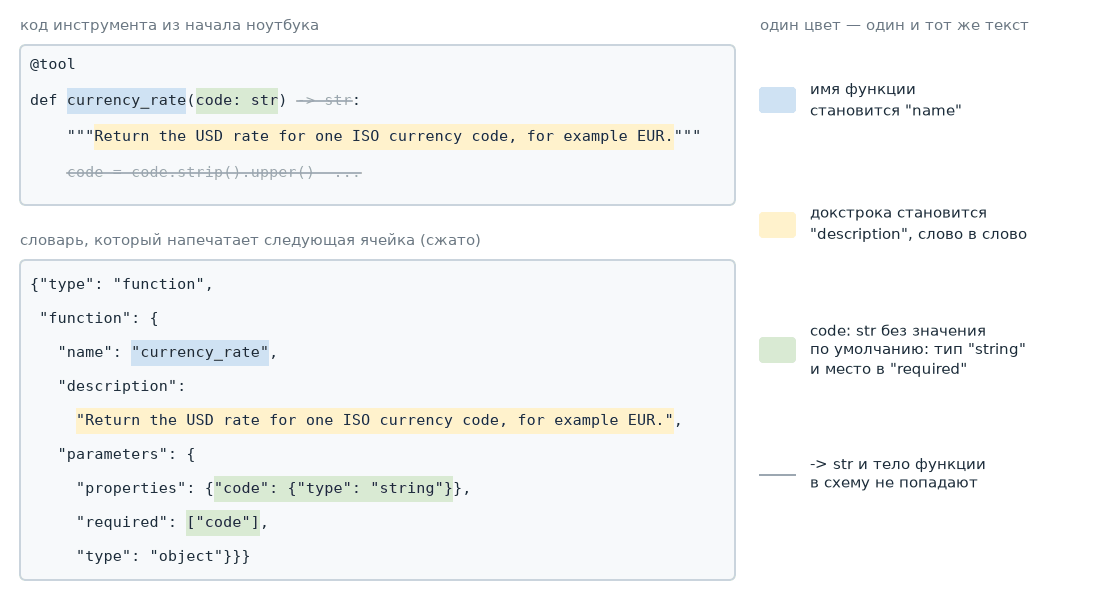

In [ ]:
# Напечатать схему @tool и аргументы bind_tools: эти описания инструментов получает модель.

import json

from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain_openai import ChatOpenAI  # его init_chat_model создает для openai:имя

# convert_to_openai_tool: та же функция строит схемы внутри ChatOpenAI.bind_tools
print(json.dumps(convert_to_openai_tool(currency_rate), indent=2))

# создание клиента не отправляет запрос
client_model = ChatOpenAI(model=os.environ["MODEL_CHEAP"],
                          api_key=os.environ["LLM_API_KEY"],
                          base_url=os.getenv("LLM_BASE_URL"))
wire_bound = client_model.bind_tools(TOOLS)  # новый объект: модель плюс аргументы запроса

# здесь формат OpenAI; клиент Gemini перед отправкой переводит схему в формат Google
print(list(wire_bound.kwargs))  # один аргумент tools: он попадет в тело каждого запроса
print([entry["function"]["name"] for entry in wire_bound.kwargs["tools"]])

In [ ]:
# Сравнить схемы и описания конвертера с parse_docstring и без него: куда попадают описания параметров.

@tool  # те же параметры и докстрока, но без parse_docstring
def convert_plain(amount: float, source: str, target: str) -> str:
    """Convert an amount between two currencies via USD.

    Args:
        amount: The amount in the source currency.
        source: ISO code the amount is in, for example EUR.
        target: ISO code to convert into, for example JPY.
    """
    return currency_convert.func(amount, source, target)  # .func — функция под @tool


# только раздел parameters, схема аргументов: у обычного @tool в нем нет описаний
print("plain @tool:")
print(json.dumps(convert_to_openai_tool(convert_plain)["function"]["parameters"], indent=2))
print("with parse_docstring=True:")
print(json.dumps(convert_to_openai_tool(currency_convert)["function"]["parameters"], indent=2))

# описание инструмента целиком: куда попали строки Args:
print("\nplain @tool, description:")
print(convert_to_openai_tool(convert_plain)["function"]["description"])
print("\nwith parse_docstring=True, description:")
print(convert_to_openai_tool(currency_convert)["function"]["description"])

**Обычный `@tool` оставляет строки `Args:` в общем описании; `parse_docstring=True` переносит их в описания параметров.**

- `Args:` — раздел докстроки в стиле Google, где каждой строкой описан один параметр
- без флага `parameters` содержит `type`, но не описания; вся докстрока со строками `Args:` остается в `description` инструмента
- с флагом у каждого параметра свое поле `description`, а в описании инструмента остается первый абзац докстроки
- имя и описания модель читает как часть промпта, поэтому схему каждого своего инструмента печатают и читают (шаг 3 практики)
- в чек-листе практики в конце ноутбука это проверка 2, «описан каждый параметр»

## Проектирование инструментов

**Курс берет правила для инструментов из статьи Anthropic «Writing effective tools for agents — with agents».**

- объединение: один инструмент решает задачу целиком; `currency_convert` пересчитывает сумму за один вызов вместо двух вызовов `currency_rate`
- общий префикс имен на предметную область, как `currency_`; по имени видно область, и имена из разных областей не совпадут
- понятные идентификаторы: коды вроде `EUR` вместо длинных случайных UUID; по данным статьи, так модель реже ошибается в идентификаторах
- экономные ответы: инструмент отдает только нужное; следующая ячейка оценивает в токенах два `ToolMessage` с одним фактом функцией `count_tokens_approximately` из `langchain_core.messages.utils`

In [ ]:
# Оценить размер двух ответов с одним курсом валюты: подробного JSON и короткой строки.

from langchain_core.messages import ToolMessage
# оценка по длине: символы / 4 и еще 3 токена на сообщение
from langchain_core.messages.utils import count_tokens_approximately

verbose = ToolMessage(  # ToolMessage — ответ инструмента, как его пишет ToolNode
    content=json.dumps({
        "status": "ok",
        "query": {"code": "EUR"},
        "result": {"base": "EUR", "quote": "USD", "rate": 1.09,
                   "retrieved_at": "2026-08-11T09:00:00Z", "source": "desk-cache"},
    }),
    tool_call_id="demo",  # без tool_call_id сообщение не создать; demo — заглушка
)
concise = ToolMessage(content="1 EUR = 1.09 USD", tool_call_id="demo")  # тот же факт

# символы — текст, роль tool и tool_call_id; деление округляется вверх
print("verbose reply:", count_tokens_approximately([verbose]), "tokens")
print("concise reply:", count_tokens_approximately([concise]), "tokens")

**По оценке `count_tokens_approximately` многословный JSON занимает 46 токенов, однострочный ответ с тем же фактом — 9.**

- это оценка: число символов делится на 4 с округлением вверх; добавляется 3 токена на сообщение; счетчики провайдера могут отличаться
- факт в обоих один, `1 EUR = 1.09 USD`; поля `status`, `query`, `retrieved_at` и `source` для ответа не нужны
- ответ инструмента остается в истории и уходит с каждым следующим запросом, поэтому лишние токены оплачиваются на каждом витке
- экономные ответы: отбирайте нужные поля, длинные списки отдавайте по страницам, длинный текст обрезайте до возврата
- ошибки с подсказкой: ответ на неверный ввод говорит, что попробовать; так делают `currency_rate`, `find_book` занятия 1 и `care_notes` занятия 2

**Следующая ячейка рисует запросы первого прогона: одна полоса — один запрос, один блок — одно сообщение.**

- серый блок — системный промпт и схемы инструментов, они уходят с каждым запросом
- голубой — вопрос человека, синий — ответ модели, оранжевый — ответ инструмента с числом его токенов
- на верхней панели ответ инструмента короткий, `concise`, на нижней длинный, `verbose` из ячейки выше
- последняя полоса — запрос со следующим вопросом «And the pound?»; его не отправляют
- длины — оценка `count_tokens_approximately` по числу символов; точные счетчики провайдера будут в разделе «Стоимость»

In [ ]:
# Нарисовать запросы первого прогона: ответ инструмента остается в истории и отправляется снова.

import matplotlib.pyplot as plt
from langchain_core.messages import HumanMessage, SystemMessage
from matplotlib.patches import Patch

# история первого прогона со следующим вопросом; запрос не отправляется
asked = result["messages"] + [HumanMessage("And the pound?")]
# перед каждым ответом модели ушел запрос со всей историей до этого ответа
requests = [asked[:i] for i, m in enumerate(asked) if m.type == "ai"] + [asked]
fixed = count_tokens_approximately([SystemMessage(PROMPT)], tools=TOOLS)  # промпт и схемы
colors = {"human": "#9ecae1", "ai": "#3182bd", "tool": "#e6550d"}  # цвет по типу сообщения
# подпись каждой полосы; последний запрос не отправляют
names = [f"request {k}" for k in range(1, len(requests))] + ["next question\n(not sent)"]

# общая шкала x позволяет сравнить длины полос на двух панелях
fig, axes = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)
panels = [(axes[0], concise, "tool reply: concise, the one-line reply counted earlier"),
          (axes[1], verbose, "tool reply: verbose, the JSON reply counted earlier")]
for ax, reply, title in panels:  # сверху короткий ответ инструмента, снизу длинный
    for row, request in enumerate(requests):  # одна полоса — один запрос
        ax.barh(row, fixed, color="#d9d9d9", edgecolor="white")  # серый: промпт и схемы
        left = fixed  # следующий блок начнется там, где кончился серый
        for m in request:
            m = reply if m.type == "tool" else m  # ответ инструмента — concise или verbose
            size = count_tokens_approximately([m])  # та же оценка, что у verbose и concise
            # блок длиной size от точки left, цвет по типу сообщения
            ax.barh(row, size, left=left, color=colors[m.type], edgecolor="white")
            if m.type == "tool":  # число только на ответе инструмента: сравнивают его
                ax.text(left + size / 2, row, str(size), ha="center", va="center", color="white")
            left += size  # конец этого блока — начало следующего
    ax.set_yticks(range(len(requests)), names)  # подпись слева от каждой полосы
    ax.invert_yaxis()  # первый запрос сверху
    ax.set_title(title)
axes[1].set_xlabel("approximate tokens: count_tokens_approximately, as for verbose and concise")
# Patch — цветной квадрат легенды с подписью
legend = [Patch(color="#d9d9d9", label="system prompt + tool schemas")]
legend += [Patch(color=c, label=kind) for kind, c in colors.items()]
fig.legend(handles=legend, loc="lower center", ncol=4)  # одна легенда на обе панели
fig.subplots_adjust(bottom=0.16, hspace=0.35)  # место под легенду
plt.show()

## Типовые сбои

**В примере разобраны две ошибки вызова инструмента: неверное имя и аргумент, который не соответствует схеме.**

- выдуманное имя — `currencyRate` вместо `currency_rate`; аргумент не по схеме — слово `"ten"` вместо числа `amount`
- следующая ячейка дает те же инструменты дешевой модели и печатает все сообщения
- в прогонах курса на Polza и OpenAI модель не ошиблась и вызвала `currency_rate` с `JPY`
- ячейка после нее делает обе ошибки сама, без модели, и печатает ответы `ToolNode`, того же класса, что внутри `create_agent`

In [ ]:
# Дать те же инструменты дешевой модели и напечатать прогон: проверить, не ошибется ли она в вызове.

clumsy = create_agent(chat_model("cheap"), TOOLS, system_prompt=PROMPT)

recovery = clumsy.invoke(
    {"messages": [{"role": "user", "content": "What is the yen worth in dollars?"}]},
    # без хуков виток — два шага, model и tools; промах добавляет виток
    config={"recursion_limit": 10},  # 10 хватает на четыре витка
)

for message in recovery["messages"]:
    message.pretty_print()

In [ ]:
# Передать ToolNode два неверных вызова и прочитать сообщения об ошибках, которые получила бы модель.

import textwrap  # textwrap.fill ниже переносит длинную строку по ширине 78 символов

from langchain_core.messages import AIMessage

broken = AIMessage(content="", tool_calls=[  # модель могла бы запросить такие вызовы
    {"name": "currencyRate", "args": {"code": "EUR"}, "id": "bad-name"},  # такого имени нет
    {"name": "currency_convert", "id": "bad-args",
     "args": {"amount": "ten", "source": "EUR", "target": "JPY"}},  # слово вместо числа
])

checker = StateGraph(MessagesState)  # ToolNode вне графа падает с ValueError
checker.add_node("tools", ToolNode(TOOLS))  # тот же класс, что create_agent ставит внутрь
checker.add_edge(START, "tools")  # из tools ребер нет: после него прогон заканчивается

# [1:] пропускает сам broken: остаются два ToolMessage, по одному на вызов
for reply in checker.compile().invoke({"messages": [broken]})["messages"][1:]:
    print("status:", reply.status)  # status=error: ошибка записана в ToolMessage
    for line in reply.content.splitlines():  # textwrap.fill склеил бы все строки в одну
        print(textwrap.fill(line.strip(), 78, initial_indent="  ", subsequent_indent="    "))
    print()

**На оба неверных вызова `ToolNode` вернул `ToolMessage` со статусом `error`; исключения не было.**

- на имя `currencyRate` `ToolNode` ответил «Error: currencyRate is not a valid tool, try one of [currency_rate, currency_convert].»
- на слово `"ten"` он вернул ошибку проверки аргумента `amount` и просьбу «Please fix the error and try again»
- в полном цикле модель читает этот текст на следующем витке и может исправить вызов
- проверка имени встроена в `ToolNode`; если инструменты запускает ваш код, как в цикле занятия 1, ее пишут сами
- при ошибке внутри самого инструмента `ToolNode` по умолчанию пробрасывает исключение, и прогон обрывается, как на занятии 2; поэтому ответ на неверный ввод возвращают строкой

## Стоимость

**Стоимость вызова модели — счетчики токенов из `usage_metadata` ее ответа, умноженные на цены провайдера.**

- `input_tokens` — вход, `output_tokens` — выход, `total_tokens` — сумма, `cache_read` — часть входа из кеша
- в кеше провайдер находит начало запроса, совпавшее с прошлым; `cache_read` уже входит в `input_tokens`, для него может действовать отдельная цена
- следующая ячейка печатает счетчики последнего ответа; на Polza 24.09.2026 вход 482, из них 256 из кеша, выход 22
- ячейка после нее рисует полосу на каждый вызов функцией `plot_usage`: светлая часть — `cache_read`, средняя — новый вход, темная — выход

In [ ]:
# Напечатать счетчики токенов последнего ответа первого прогона: по ним считают стоимость вызова.

final = result["messages"][-1]  # последний ответ первого прогона

print("usage_metadata:", final.usage_metadata)  # счетчики в формате, общем для провайдеров
# cache_read — часть входа, которую провайдер взял из кеша
print("cached input:  ", final.usage_metadata.get("input_token_details"))
# поля ответа, которые собрал класс модели; ключи у провайдеров разные
print("response_metadata keys:", list(final.response_metadata))

In [ ]:
# Нарисовать счетчики первого прогона: вход из кеша, новый вход и выход для расчета стоимости.

import matplotlib.pyplot as plt


# полоса на каждый вызов модели; вернет счетчики для формулы стоимости
def plot_usage(messages, title) -> dict:
    calls = {}  # подпись полосы -> счетчики этого вызова модели
    replies = [m for m in messages if m.type == "ai"]  # один ответ модели — один вызов
    for k, m in enumerate(replies, 1):  # k — номер вызова с единицы, он попадет в подпись
        u = m.usage_metadata
        if not u:  # нет счетчиков — нечего рисовать
            continue
        details = u.get("input_token_details") or {}  # не каждый провайдер присылает детали
        cached = details.get("cache_read") or 0  # без счетчика код подставляет ноль
        new = u["input_tokens"] - cached  # input_tokens уже включает кеш
        calls[f"call {k}"] = {"new_input": new, "cached_input": cached, "output": u["output_tokens"]}
    fig, ax = plt.subplots(figsize=(10, 1.6 + 0.6 * len(calls)))  # больше вызовов — выше рисунок
    left = [0] * len(calls)  # где кончается уже нарисованная часть каждой полосы
    for key, color, name in [("cached_input", "#c6dbef", "cached input (cache_read)"),
                             ("new_input", "#4292c6", "new input"),
                             ("output", "#08306b", "output")]:
        sizes = [c[key] for c in calls.values()]  # эта часть у каждого вызова
        # сразу на всех полосах; каждая часть начинается в конце предыдущей
        ax.barh(list(calls), sizes, left=left, height=0.5, color=color, label=name)
        left = [a + b for a, b in zip(left, sizes)]
    for (row, c), end in zip(calls.items(), left):  # подпись справа от конца полосы
        total_in = c["cached_input"] + c["new_input"]  # весь вход, как в input_tokens
        ax.text(end, row, f"  input {total_in} = {c['cached_input']} cached"
                f" + {c['new_input']} new; output {c['output']}", va="center")
    ax.set_xlim(0, 1.6 * max(left, default=1))  # место под подписи
    ax.invert_yaxis()  # первый вызов сверху
    ax.set_xlabel("tokens from usage_metadata: bar length is tokens, not money")
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=False)  # под осью
    plt.show()
    return calls  # эти счетчики возьмет последняя ячейка с кодом, для формулы стоимости


# присваивание: иначе Jupyter напечатает под рисунком возвращенный словарь
first_run = plot_usage(result["messages"], "first run: one bar per model call")

**Выходные токены оплачиваются, даже когда ответ модели пуст или оборван.**

- `finish_reason` с занятия 1 — причина остановки ответа; `length` значит, что кончился бюджет выходных токенов
- в LangChain он лежит в `response_metadata` ответа; ключ `finish_reason` есть в выводе счетчиков выше
- в примере токены скрытых рассуждений входят в `output_tokens`, хотя в `content` их нет
- на рисунке схема двух запросов занятия 1 с бюджетом 16 токенов; с рассуждениями `output_token_details['reasoning']` равен `output_tokens`, `content` пуст
- без рассуждений бюджет ушел на видимый текст, и он оборван раньше строки Action; в обоих случаях `finish_reason` — `length`

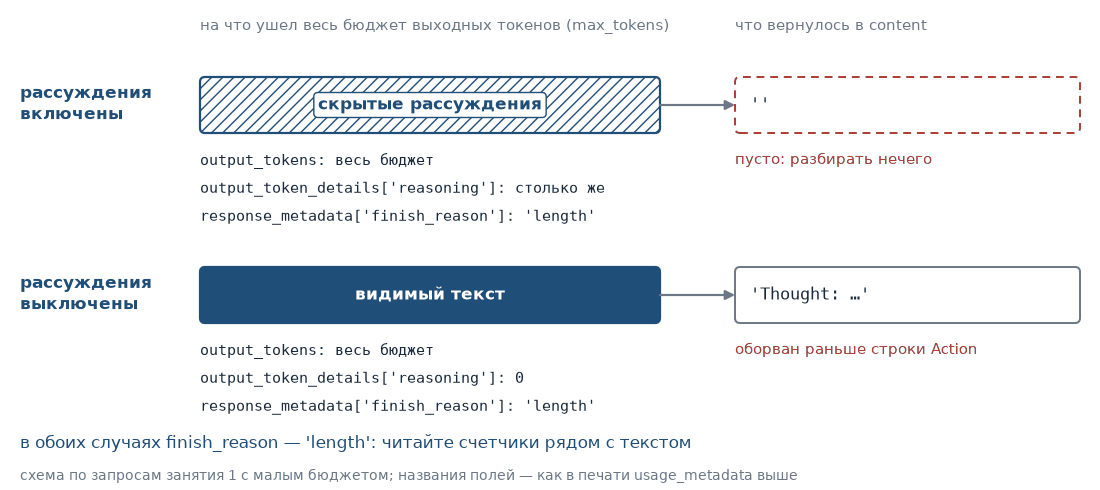

## Правило о данных

**Все, что вернул инструмент, уходит провайдеру модели вместе с историей и снова с каждым следующим запросом.**

- так уходят файлы, веб-страницы, письма и ответы чужих API, которые прочитал инструмент
- `PIIMiddleware` по умолчанию ищет заданный тип данных только в сообщении пользователя (`apply_to_input=True`), ответы инструментов не проверяет (`apply_to_tool_results=False`)
- на рисунке второй запрос первого прогона; синим отмечено то, что проверил бы `PIIMiddleware` с настройками по умолчанию
- поэтому правило курса на весь семестр: в инструментах и проекте только выдуманные данные; `PIIMiddleware` его не отменяет

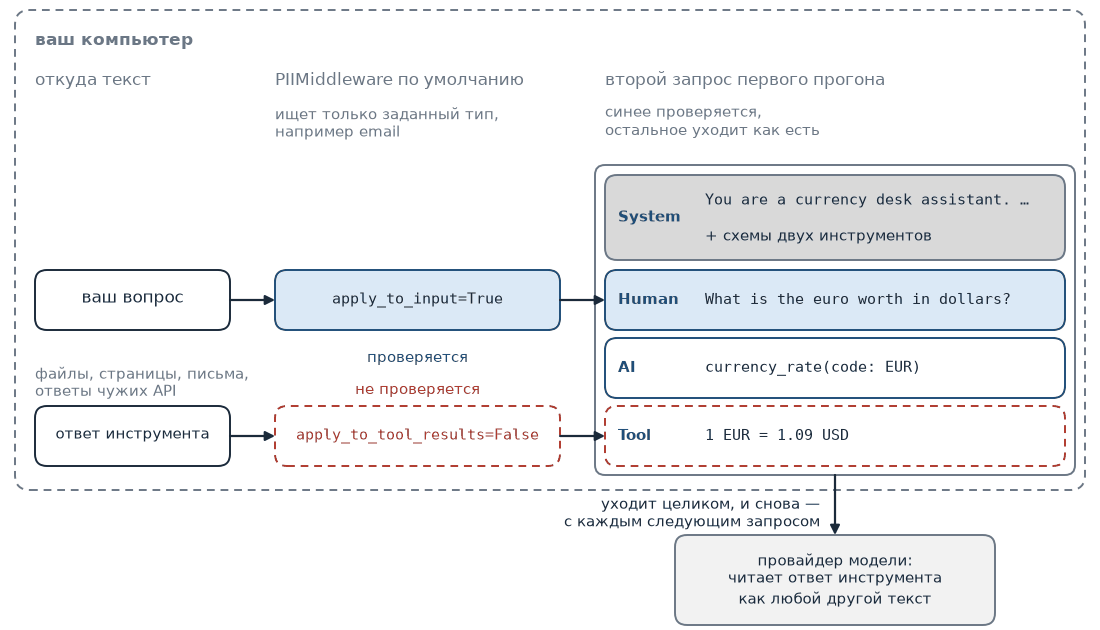

## Трейс

**Трейс хранит события одного прогона; его записывает `CallbackHandler` из `langfuse.langchain`, как на занятии 2.**

- обработчик передают в `config["callbacks"]`; каждый `invoke` с ним дает трейс, спан хранит отдельный запуск узла или вызов с его длительностью
- на рисунке трейс прогона курса; почти все 3,70 с заняли два вызова модели, узел `tools` работал 2 мс
- справа счетчики Langfuse; там `input` без кеша, а `input_tokens` первого вызова — это 21 + 384 = 405
- клиент Langfuse отправляет спаны пачками раз в 5 секунд и при выходе из процесса; `client.flush()` отправляет их сразу

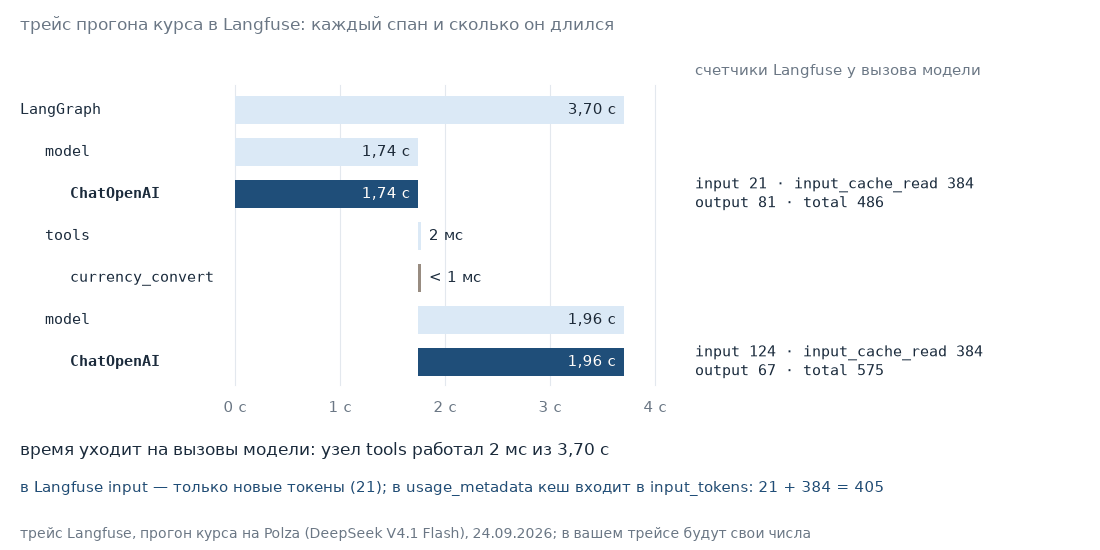

**Следующая ячейка прогоняет первого агента с трейсом, рисует его вызовы модели и печатает формулу стоимости каждого.**

- нужен Langfuse с занятия 2; `get_client()` берет `LANGFUSE_HOST` и ключи из `.env`, `auth_check()` дает `up: True`, если сервер доступен и ключи подошли
- вопрос «Turn 250 francs into yen.»; после ответа `client.flush()` отправляет трейс, а `plot_usage` рисует полосы
- полоса — один вызов: светлая часть — вход из кеша, средняя — новый вход, темная — выход
- при положительных ценах вызов с большим числом токенов во всех трех частях дороже; иначе сравните формулы с ценами провайдера
- `P_input`, `P_cached`, `P_output` — цена одного токена: цена за 1M токенов со страницы провайдера, деленная на миллион

In [ ]:
# Прогнать агента с трейсом Langfuse и напечатать формулу стоимости каждого вызова модели и всего прогона.

from langfuse import get_client
# трейс — запись одного прогона; CallbackHandler строит его из событий LangChain
from langfuse.langchain import CallbackHandler

client = get_client()  # берет LANGFUSE_HOST и оба ключа из окружения
# auth_check() проверяет ключи на сервере: True, при ошибке — исключение
print("server:", os.getenv("LANGFUSE_HOST"), "| up:", client.auth_check())

handler = CallbackHandler()  # одного обработчика хватит; каждый invoke — свой трейс
traced = agent.invoke(
    {"messages": [{"role": "user", "content": "Turn 250 francs into yen."}]},
    # спан — запись одного запуска узла, инструмента или модели, с длительностью
    config={"recursion_limit": 8, "callbacks": [handler]},  # handler получит события прогона
)

client.flush()  # отправить спаны сейчас; без flush они уходят пакетом раз в 5 секунд

print(traced["messages"][-1].content)

# plot_usage объявлена в ячейке с графиком счетчиков
calls = plot_usage(traced["messages"], "traced run: one bar per model call")
# шаблон стоимости одного вызова; цен нет: P_* берут со страницы провайдера
formula = "{new_input} × P_input + {cached_input} × P_cached + {output} × P_output"
for name, c in calls.items():  # одна формула на каждую полосу графика
    print(f"{name}: cost =", formula.format(**c))
# каждая часть входа и выход, сложенные по всем вызовам
run = {key: sum(c[key] for c in calls.values()) for key in ("new_input", "cached_input", "output")}
print("run:    cost =", formula.format(**run))  # та же формула для всего прогона
print("the longest bar is not always the priciest call: put the prices in, then compare")
print("P_*: the price of one token = the price per 1M tokens / 1,000,000")

**Найдите в трейсе самый дорогой вызов модели и посчитайте стоимость прогона по ценам своего провайдера.**

- откройте последний трейс в Langfuse по адресу из `LANGFUSE_HOST` и сверьте его счетчики с формулами из вывода ячейки
- в трейсе курса на рисунке из карточки «Трейс» второй вызов прочитал больше новых токенов, 124 против 21
- у первого больше выходных токенов, 81 против 67; какой вызов дороже, зависит от цен
- вход растет от вызова к вызову, потому что в каждый следующий запрос снова входит вся история
- на неоднозначный вопрос модель может переспросить без вызова инструмента; на OpenAI 17.09.2026 она спросила, какие франки имеются в виду

## Практика

**Перенесите ассистента из занятия 2 на `create_agent` в своем репозитории.**

1. замените граф занятия 2 одним вызовом `create_agent`; старый код останется в истории git
2. добавьте три инструмента своей области (валюты заняты): каждый решает задачу целиком; общий префикс имен, подсказка при неверном вводе
3. напечатайте схему каждого инструмента через `convert_to_openai_tool` и прочитайте то, что прочитает модель
4. обязательный middleware: хук `wrap_tool_call`, который пишет в лог имя и аргументы каждого вызова инструмента

**Затем прогоните один разговор с трейсом и разберите его по счетчикам.**

5. задайте вопрос, на который нельзя ответить без двух вызовов инструментов
6. найдите в трейсе самый дорогой вызов модели и объясните по счетчикам, почему именно он
7. запишите расчет стоимости прогона одним предложением, взяв цены со страницы своего провайдера
8. если трейс не появился в Langfuse, подождите 5 секунд или вызовите `flush()`; если это не помогло, проверьте настройки

**Обязательный артефакт — файл `runs/session-03.md` в коммите вашего репозитория.**

- напечатанные схемы трех ваших инструментов
- расшифровка разговора с двумя вызовами инструментов
- стоимость прогона одним предложением: новые токены входа, токены из кеша и выходные, умноженные на цены провайдера
- выгруженный трейс Langfuse (JSON) отдельным файлом в том же коммите

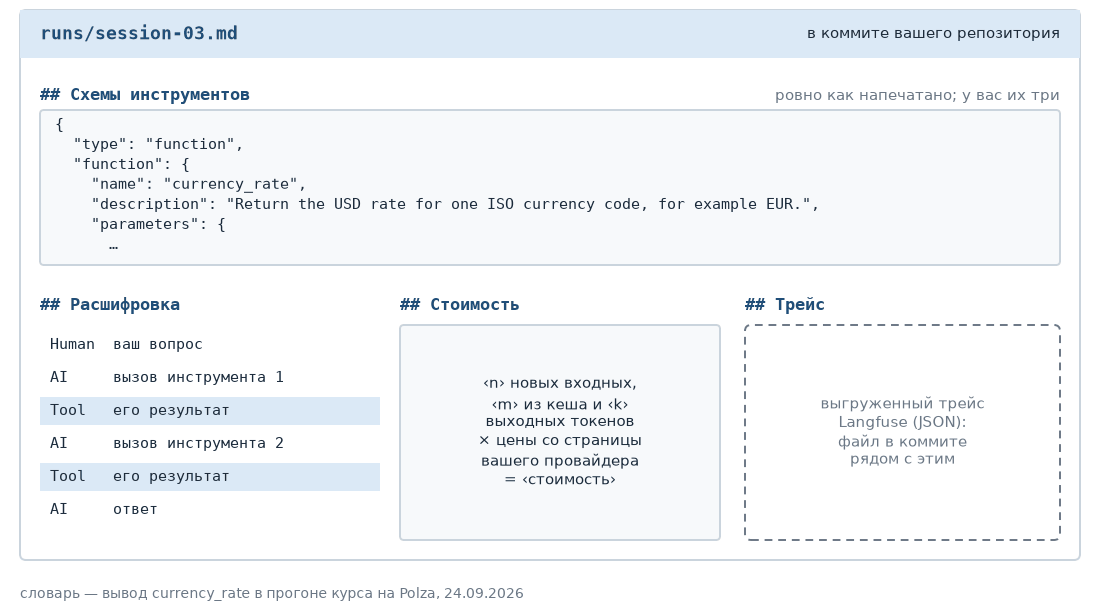

**Два задания для тех, кто закончил раньше.**

- напишите `wrap_tool_call`, который запрещает один инструмент по имени: возвращает `ToolMessage` с причиной отказа и не вызывает `handler`
- разбейте один инструмент на три мелких, задайте тот же вопрос и сравните трейсы до и после
- сравните число токенов: так видно, увеличило ли разбиение расходы вашего агента

**Чек-лист практики держите на экране: пять проверок инструмента и две ловушки.**

- проверки 1–5 — правила для инструментов из разделов «Что уходит в запрос к модели» и «Проектирование инструментов»
- правила объединения в таблице нет; его проверяет второе задание выше: разбить инструмент на три и сравнить трейсы
- для каждой проверки указано, где смотреть результат и каким он должен быть
- сначала сверьте свой вывод с таблицей, потом правьте промпт
- для каждой ловушки указаны признаки и способ проверки; если застряли, спросите преподавателя

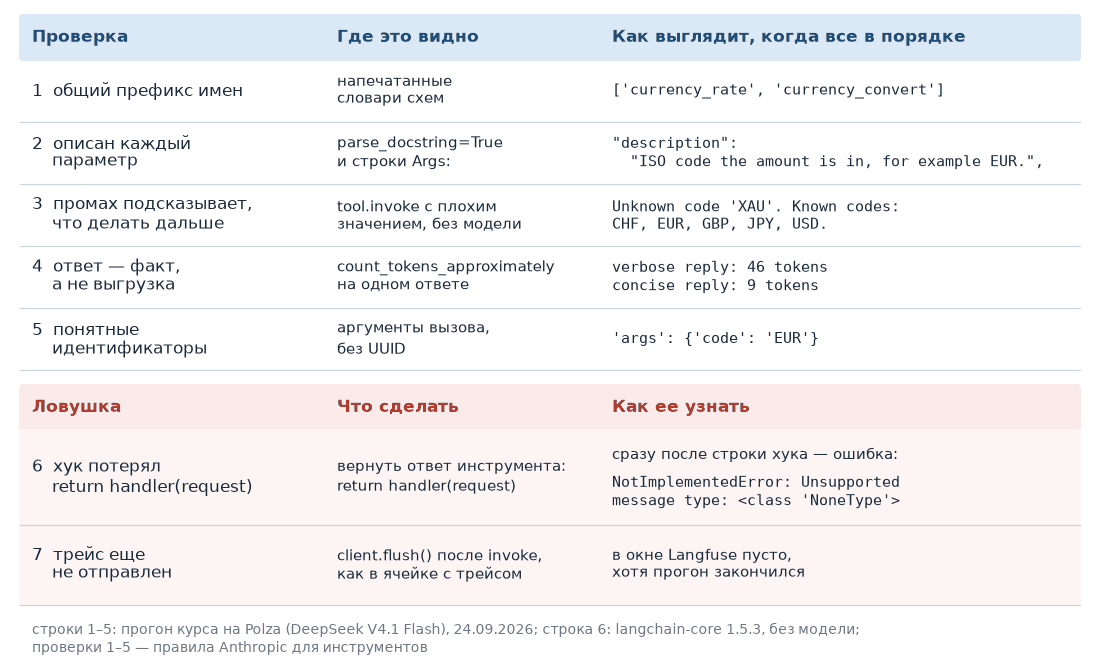

**Сегодня начинается выбор темы семестрового проекта.**

- на занятии 4 обсуждают направления проектов и требования к заявке; на занятии 5 темы утверждают и назначают пары взаимопроверки
- `create_agent` с middleware — рекомендуемая стартовая архитектура проекта
- критерий защиты «Архитектура и код» проверяет, что инструменты спроектированы по правилам занятия 3, или объяснено, почему выбран другой подход
- эти правила собраны в разделе «Проектирование инструментов» и в чек-листе выше
- трейсинг теперь обязателен для всего, что вызывает модель; критерий «Эксплуатация и безопасность» требует его и стоимость прогона по своим трейсам

## Сегодня в одной карточке

**`create_agent` собирает граф занятия 2 одним вызовом; свой код в его цикл добавляют хуками middleware.**

**Теперь вы можете объяснить:**
- `@tool` строит JSON-схему из имени функции, аннотаций и докстроки, и эта схема уходит с каждым запросом
- `wrap_tool_call` видит каждый вызов до запуска инструмента; свой `ToolMessage` без вызова `handler` запрещает вызов
- многословный ответ инструмента остается в истории и оплачивается снова с каждым запросом; лишние данные убирают до возврата
- выходные токены оплачиваются и за пустой ответ; причину показывают `usage_metadata` и `finish_reason`

**В репозитории:** `runs/session-03.md` со схемами трех инструментов, расшифровкой с двумя вызовами и стоимостью; трейс (JSON) — отдельным файлом рядом.
**Ловушка дня:** `create_react_agent` импортируется без предупреждения и предупреждает об устаревании только при вызове.
**Спросите себя:** откуда берется JSON-схема инструмента и какой флаг решает, попадут ли строки `Args:` в описания параметров?
**В следующий раз:** управление контекстом — длинный диалог, который не помещается в контекст модели, и состояние после перезапуска.